# NB02 — Chunking Strategy Comparison

This notebook compares two Markdown chunking strategies for the KDK documentation RAG pipeline:

- **Manual heading split**: split at `##` headings, re-split oversized sections with character overlap (current `scripts/chunk_md.py` approach)
- **LangChain RecursiveCharacterTextSplitter**: recursive splitting with heading-aware separators and controlled chunk size / overlap

Both strategies use the same embedding model (`nomic-ai/nomic-embed-text-v1.5` via SentenceTransformer) and the same vector database (Qdrant), so the only experimental variable is the chunking method.

**Sections:**
1. Configuration and test questions
2. Chunking strategies
3. Chunk statistics comparison
4. Embedding and Qdrant ingestion
5. Retrieval evaluation (LLM-as-Judge)
6. Visualization
7. Statistical test and conclusions

---
## 1. Configuration and Test Questions

In [1]:
import json
import os
import re
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

# Allow imports from scripts/ and src/
ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR / "scripts"))
sys.path.insert(0, str(ROOT_DIR / "src"))
from token_tracker import TrackedClient
from corpus_filter import scan_corpus

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120

print("All imports OK")

/home/kalisio/miniconda3/envs/knowledge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


In [ ]:
# ── Paths and constants ──
KDK_DIR = ROOT_DIR / "data" / "kdk"
DOCS_DIR = KDK_DIR / "docs"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
EMBEDDING_MODEL = "nomic-ai/nomic-embed-text-v1.5"

judge = TrackedClient(source="nb02")

MANUAL_COLLECTION = "nb02_manual_heading"
LANGCHAIN_COLLECTION = "nb02_langchain_rct"
RESET_ARTIFACTS = True

MANUAL_MAX_CHARS = 1500
MANUAL_OVERLAP_CHARS = 200
LANGCHAIN_CHUNK_SIZE = 1000
LANGCHAIN_CHUNK_OVERLAP = 200

TOP_K = 20
EMBED_BATCH_SIZE = 32

EVAL_PATH = OUTPUT_DIR / "nb02_retrieval_eval.json"

# ── Corpus filtering (aligned with NB01) ──
kdk_scan = scan_corpus(KDK_DIR)
md_files = sorted(
    r.path for r in kdk_scan.included
    if r.zone == "docs" and r.extension == ".md"
)
print(f"Corpus filter: {kdk_scan.total} scanned, {len(kdk_scan.included)} included, {len(md_files)} MD docs retained")

print(f"Docs dir: {DOCS_DIR} (exists={DOCS_DIR.exists()})")
print(f"Qdrant:   {QDRANT_URL}")
print(f"Judge:    {judge.provider} / model={judge.model}")
print(f"Embedding: {EMBEDDING_MODEL}")

In [3]:
# ── Test questions ──
# Priority questions from team feedback (how-to, component discovery, code lookup).
# Supplemented with factual and architecture questions for broader coverage.

QUESTIONS = [
    # How-to (from team: "how can I add a service / create an activity / configure components")
    {"id": 1,  "category": "howto",     "question": "How can I add a new service to my application?"},
    {"id": 2,  "category": "howto",     "question": "How can I create an activity to manage the items of a service?"},
    {"id": 3,  "category": "howto",     "question": "How should I configure components in KDK?"},
    {"id": 4,  "category": "howto",     "question": "How do I add a custom map layer to a KDK application?"},
    {"id": 5,  "category": "howto",     "question": "How do I register a hook on a service in KDK?"},

    # Component / utility / composable discovery (from team: "is there a composable for X?")
    {"id": 6,  "category": "discovery", "question": "Is there a composable for handling weather data in KDK?"},
    {"id": 7,  "category": "discovery", "question": "Does KDK provide a utility for managing map layers?"},
    {"id": 8,  "category": "discovery", "question": "Is there a component for uploading files in KDK?"},
    {"id": 9,  "category": "discovery", "question": "Does KDK have a mixin or composable for handling user selection on a map?"},
    {"id": 10, "category": "discovery", "question": "Is there a utility for converting geographic coordinates in KDK?"},

    # Code lookup (from team: "find all places where X is implemented")
    {"id": 11, "category": "code",      "question": "Where is the features service implemented in KDK?"},
    {"id": 12, "category": "code",      "question": "Which file defines the catalog service?"},
    {"id": 13, "category": "code",      "question": "What methods does the base activity mixin provide?"},
    {"id": 14, "category": "code",      "question": "How are permissions and abilities defined in KDK?"},
    {"id": 15, "category": "code",      "question": "What are the available map mixins and what do they do?"},

    # Factual / architecture
    {"id": 16, "category": "factual",   "question": "What does KDK stand for?"},
    {"id": 17, "category": "factual",   "question": "What is the main goal of the Kalisio Development Kit?"},
    {"id": 18, "category": "factual",   "question": "What kind of applications is KDK designed to help build?"},
    {"id": 19, "category": "factual",   "question": "What license is used by KDK?"},
    {"id": 20, "category": "factual",   "question": "What are the three main API parts of a KDK subsystem?"},

    # Architecture / concepts
    {"id": 21, "category": "arch",      "question": "How does KDK handle data segregation between organizations?"},
    {"id": 22, "category": "arch",      "question": "What role do services play in the KDK architecture?"},
    {"id": 23, "category": "arch",      "question": "How is the global architecture of a KDK application structured?"},
    {"id": 24, "category": "arch",      "question": "What is meant by context in KDK data segregation?"},
    {"id": 25, "category": "arch",      "question": "How does KDK separate client and server concerns?"},
]

print(f"Total test questions: {len(QUESTIONS)}")
for q in QUESTIONS[:5]:
    print(f"  [{q['id']:>2}] ({q['category']}) {q['question']}")

Total test questions: 25
  [ 1] (howto) How can I add a new service to my application?
  [ 2] (howto) How can I create an activity to manage the items of a service?
  [ 3] (howto) How should I configure components in KDK?
  [ 4] (howto) How do I add a custom map layer to a KDK application?
  [ 5] (howto) How do I register a hook on a service in KDK?


---
## 2. Chunking Strategies

In [4]:
# ── Strategy A: Manual heading split (mirrors scripts/chunk_md.py) ──

def get_doc_title(lines: list[str], fallback: str) -> str:
    for line in lines:
        if line.startswith("# ") and not line.startswith("## "):
            return line[2:].strip()
    return fallback


def split_oversized(text: str, max_chars: int = MANUAL_MAX_CHARS,
                    overlap: int = MANUAL_OVERLAP_CHARS) -> list[str]:
    if len(text) <= max_chars:
        return [text]
    parts = []
    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        parts.append(text[start:end].strip())
        if end >= len(text):
            break
        start = max(end - overlap, start + 1)
    return [p for p in parts if p]


def chunk_manual_heading(files: list[Path], base_dir: Path) -> list[dict]:
    chunks = []
    for filepath in files:
        text = filepath.read_text(encoding="utf-8")
        lines = text.splitlines()
        rel_path = str(filepath.relative_to(base_dir))
        doc_title = get_doc_title(lines, filepath.stem)

        sections = []
        current_title = doc_title
        current_lines = []
        for line in lines:
            if line.startswith("## "):
                if current_lines:
                    sections.append((current_title, "\n".join(current_lines).strip()))
                current_title = line[3:].strip()
                current_lines = []
            else:
                current_lines.append(line)
        if current_lines:
            sections.append((current_title, "\n".join(current_lines).strip()))

        chunk_index = 0
        for section_title, section_text in sections:
            for part in split_oversized(section_text):
                chunks.append({
                    "text": part,
                    "metadata": {
                        "source": rel_path,
                        "doc_title": doc_title,
                        "section_title": section_title,
                        "chunk_index": chunk_index,
                    },
                })
                chunk_index += 1
    return chunks


manual_chunks = chunk_manual_heading(md_files, DOCS_DIR)
print(f"Manual heading chunks: {len(manual_chunks)}")

Manual heading chunks: 823


In [5]:
# ── Strategy B: LangChain RecursiveCharacterTextSplitter ──

langchain_splitter = RecursiveCharacterTextSplitter(
    chunk_size=LANGCHAIN_CHUNK_SIZE,
    chunk_overlap=LANGCHAIN_CHUNK_OVERLAP,
    separators=["\n## ", "\n### ", "\n\n", "\n", " "],
)


def chunk_langchain_rct(files: list[Path], base_dir: Path) -> list[dict]:
    chunks = []
    for filepath in files:
        text = filepath.read_text(encoding="utf-8")
        rel_path = str(filepath.relative_to(base_dir))
        doc_title = filepath.stem
        for line in text.splitlines():
            if line.startswith("# ") and not line.startswith("## "):
                doc_title = line[2:].strip()
                break
        docs = langchain_splitter.create_documents(
            texts=[text],
            metadatas=[{"source": rel_path, "doc_title": doc_title, "section_title": doc_title}],
        )
        for doc in docs:
            chunks.append({
                "text": doc.page_content.strip(),
                "metadata": dict(doc.metadata),
            })
    return chunks


langchain_chunks = chunk_langchain_rct(md_files, DOCS_DIR)
print(f"LangChain RCT chunks: {len(langchain_chunks)}")

LangChain RCT chunks: 873


---
## 3. Chunk Statistics Comparison

In [6]:
manual_lengths = [len(c["text"]) for c in manual_chunks]
lc_lengths = [len(c["text"]) for c in langchain_chunks]

stats = pd.DataFrame({
    "Metric": ["Total chunks", "Mean length (chars)", "Median length", "Max length",
               "Min length", "Std dev", "Chunks < 50 chars", "Chunks > 1500 chars"],
    "Manual (## split)": [
        len(manual_lengths),
        f"{np.mean(manual_lengths):.0f}",
        f"{np.median(manual_lengths):.0f}",
        max(manual_lengths),
        min(manual_lengths),
        f"{np.std(manual_lengths):.0f}",
        sum(1 for l in manual_lengths if l < 50),
        sum(1 for l in manual_lengths if l > 1500),
    ],
    "LangChain (RCT 1000/200)": [
        len(lc_lengths),
        f"{np.mean(lc_lengths):.0f}",
        f"{np.median(lc_lengths):.0f}",
        max(lc_lengths),
        min(lc_lengths),
        f"{np.std(lc_lengths):.0f}",
        sum(1 for l in lc_lengths if l < 50),
        sum(1 for l in lc_lengths if l > 1500),
    ],
})
print(stats.to_string(index=False))

             Metric Manual (## split) LangChain (RCT 1000/200)
       Total chunks               823                      873
Mean length (chars)               650                      604
      Median length               400                      660
         Max length              1500                      999
         Min length                 0                        3
            Std dev               564                      305
  Chunks < 50 chars               103                       45
Chunks > 1500 chars                 0                        0


/tmp/ipykernel_908817/1808064022.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x="strategy", y="length",


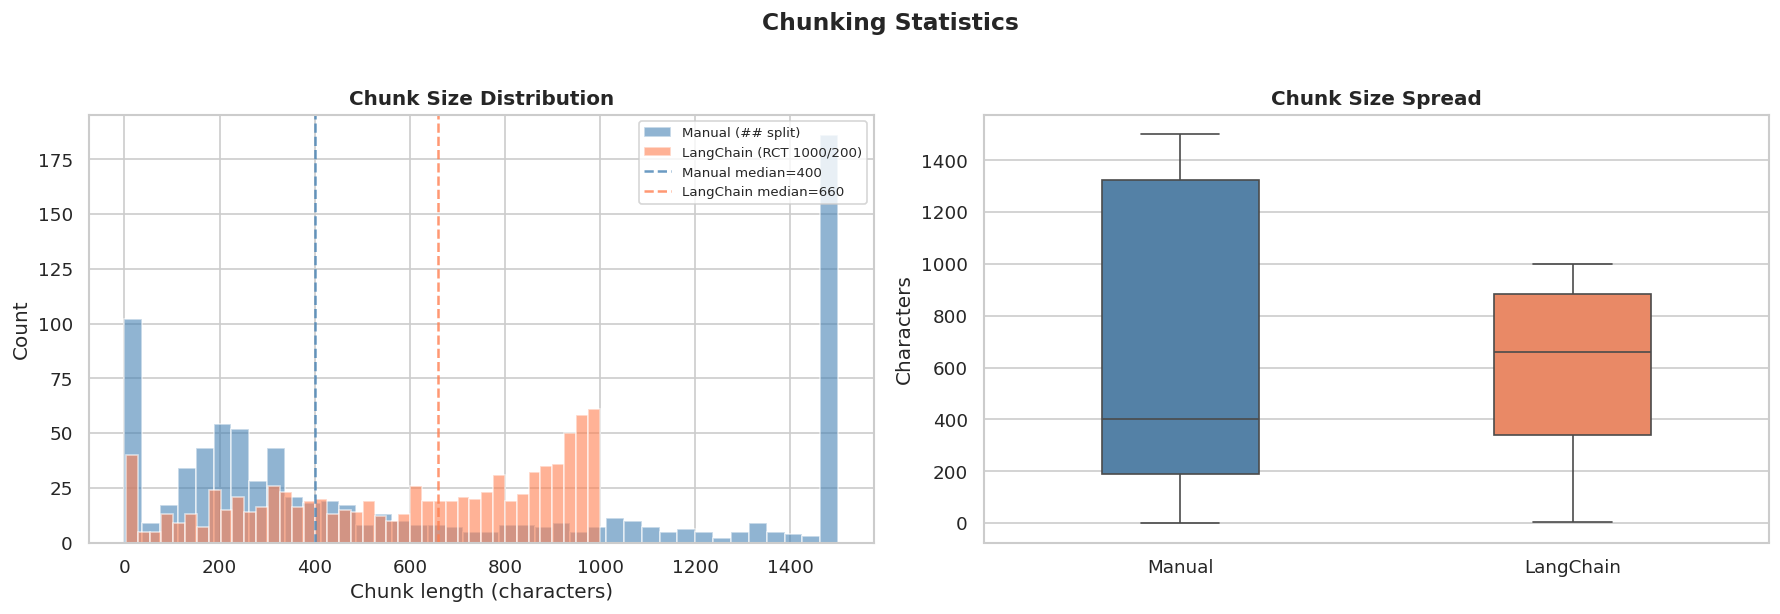

In [7]:
# ── Chunk size distribution histogram ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Overlapping histogram
ax = axes[0]
ax.hist(manual_lengths, bins=40, alpha=0.6, label="Manual (## split)", color="steelblue", edgecolor="white")
ax.hist(lc_lengths, bins=40, alpha=0.6, label="LangChain (RCT 1000/200)", color="coral", edgecolor="white")
ax.axvline(np.median(manual_lengths), color="steelblue", linestyle="--", alpha=0.8, label=f"Manual median={np.median(manual_lengths):.0f}")
ax.axvline(np.median(lc_lengths), color="coral", linestyle="--", alpha=0.8, label=f"LangChain median={np.median(lc_lengths):.0f}")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)

# (b) Box plot of chunk sizes
ax = axes[1]
box_data = pd.DataFrame({
    "length": manual_lengths + lc_lengths,
    "strategy": ["Manual"] * len(manual_lengths) + ["LangChain"] * len(lc_lengths),
})
sns.boxplot(data=box_data, x="strategy", y="length",
            palette={"Manual": "steelblue", "LangChain": "coral"}, ax=ax, width=0.4)
ax.set_title("Chunk Size Spread", fontsize=12, fontweight="bold")
ax.set_ylabel("Characters")
ax.set_xlabel("")

plt.suptitle("Chunking Statistics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Embedding and Qdrant Ingestion

Both chunk sets are embedded with the same model (`nomic-ai/nomic-embed-text-v1.5`) so the only variable is the chunking strategy.

In [8]:
# ── Load embedding model ──
print(f"Loading embedding model: {EMBEDDING_MODEL}")
embed_model = SentenceTransformer(EMBEDDING_MODEL, trust_remote_code=True)
print(f"Model loaded. Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

Loading embedding model: nomic-ai/nomic-embed-text-v1.5


<All keys matched successfully>


Model loaded. Embedding dimension: 768


In [9]:
# ── Helper functions ──
qdrant = QdrantClient(url=QDRANT_URL)


def reset_collections():
    for collection in [MANUAL_COLLECTION, LANGCHAIN_COLLECTION]:
        if qdrant.collection_exists(collection):
            qdrant.delete_collection(collection)
            print(f"Deleted collection: {collection}")
    if EVAL_PATH.exists():
        EVAL_PATH.unlink()
        print(f"Removed cache: {EVAL_PATH.name}")


def embed_texts(texts: list[str], batch_size: int = EMBED_BATCH_SIZE) -> np.ndarray:
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[start : start + batch_size]
        vectors.append(embed_model.encode(batch, show_progress_bar=False))
    return np.vstack(vectors)


def ingest_chunks(collection_name: str, chunks: list[dict]) -> None:
    texts = [c["text"] for c in chunks]
    vectors = embed_texts(texts)

    if qdrant.collection_exists(collection_name):
        qdrant.delete_collection(collection_name)
    qdrant.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=vectors.shape[1], distance=Distance.COSINE),
    )

    points = [
        PointStruct(
            id=i,
            vector=vectors[i].tolist(),
            payload={"text": chunks[i]["text"], **chunks[i]["metadata"]},
        )
        for i in range(len(chunks))
    ]
    qdrant.upsert(collection_name=collection_name, points=points)
    info = qdrant.get_collection(collection_name)
    print(f"{collection_name}: {info.points_count} points (dim={vectors.shape[1]})")


if RESET_ARTIFACTS:
    reset_collections()

ingest_chunks(MANUAL_COLLECTION, manual_chunks)
ingest_chunks(LANGCHAIN_COLLECTION, langchain_chunks)

Deleted collection: nb02_manual_heading
Deleted collection: nb02_langchain_rct
Removed cache: nb02_retrieval_eval.json


Embedding: 100%|██████████| 26/26 [05:23<00:00, 12.46s/it]


nb02_manual_heading: 823 points (dim=768)


Embedding: 100%|██████████| 28/28 [03:48<00:00,  8.16s/it]


nb02_langchain_rct: 873 points (dim=768)


---
## 5. Visual Retrieval Comparison

Side-by-side display of top-5 retrieved chunks for each strategy.
This gives a direct, human-readable view of chunking quality without relying on an LLM judge.

*The LLM-as-Judge evaluation (sections 6–7) is commented out. Uncomment to re-enable.*

In [10]:
# ── Retrieval and visual comparison functions ──

VISUAL_K = 5


def retrieve(question: str, collection_name: str, k: int = TOP_K):
    """Retrieve top-k chunks from a Qdrant collection."""
    query_vector = embed_model.encode(question).tolist()
    return qdrant.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=k,
        with_payload=True,
    ).points


def print_results(question: str, collection_name: str, label: str, k: int = VISUAL_K):
    """Print top-k retrieved chunks for one collection (similar to query_qdrant.py)."""
    points = retrieve(question, collection_name, k)
    print(f"--- {label} (top {k}) ---")
    print()
    for rank, point in enumerate(points, start=1):
        payload = point.payload or {}
        source = payload.get("source", "")
        section = payload.get("section_title", "")
        text = payload.get("text", "")
        preview = text[:300].replace("\n", " ")
        print(f"  [{rank}] score={point.score:.4f}  |  {source}  |  section: {section}")
        print(f"      {preview}")
        if len(text) > 300:
            print(f"      ... ({len(text)} chars total)")
        print()


def compare_retrieval(question: str, k: int = VISUAL_K):
    """Query both collections and display results side by side."""
    print("=" * 80)
    print(f"QUESTION: {question}")
    print("=" * 80)
    print()
    print_results(question, MANUAL_COLLECTION, "Manual (## split)", k)
    print_results(question, LANGCHAIN_COLLECTION, "LangChain (RCT 1000/200)", k)


print("Retrieval and visual comparison functions ready.")

Retrieval and visual comparison functions ready.


In [11]:
# ── Fixed question: "How can I add a new service to my application?" ──
compare_retrieval("How can I add a new service to my application?")

QUESTION: How can I add a new service to my application?

--- Manual (## split) (top 5) ---

  [1] score=0.6424  |  api/map/services.md  |  section: Services
      # Services

  [2] score=0.6424  |  api/core/services.md  |  section: Services
      # Services

  [3] score=0.6424  |  api/core/utilities/utils.services.md  |  section: Services
      # Services

  [4] score=0.6380  |  api/core/mixins/mixins.service.md  |  section: Service
      # Service

  [5] score=0.6367  |  api/core/application.md  |  section: Application API
      fix and context ID) and only refer to it by its "usual" name.  If no context is given, the current context set in the the store will be retrieved (if any) and the associated contextual or global service returned (if any).  > On the client side this will also instanciate the service on the first call
      ... (1500 chars total)

--- LangChain (RCT 1000/200) (top 5) ---

  [1] score=0.6914  |  api/core/application.md  |  section: Application
      Create a new

In [12]:
# ── Random question from test_questions.json ──
import random

test_questions_path = OUTPUT_DIR / "test_questions.json"
test_bank = json.loads(test_questions_path.read_text(encoding="utf-8"))
random_q = random.choice(test_bank["questions"])

print(f"Random pick: [{random_q['id']}] ({random_q['category']}, {random_q['difficulty']})")
print()
compare_retrieval(random_q["question"])

Random pick: [kdk-031] (discovery, medium)

QUESTION: Is there a utility for converting geographic coordinates in KDK?

--- Manual (## split) (top 5) ---

  [1] score=0.6903  |  api/map/components.md  |  section: Position indicator
      The **k-position-indicator** is used to display the geographical coordinates of the current mouse position.

  [2] score=0.6846  |  api/map/utilities/utils.location.md  |  section: Overview
      This module provides utility functions for parsing, formatting, and filtering geographic coordinates and geocoding results.

  [3] score=0.6514  |  api/map/composables.md  |  section: Location
      ### [useLocation](./composables/composables.location.md)  Provides reactive geocoder configuration and location search capabilities. Integrates with the KDK `Geocoder` and `Geolocation` services with optional filtering based on the current activity project.

  [4] score=0.6437  |  api/map/composables/composables.location.md  |  section: Overview
      `useLocation(

In [ ]:
# ── LLM-as-Judge functions (commented out — using visual comparison instead) ──

# JUDGE_PROMPT = """You are evaluating retrieval quality for a RAG system.
#
# Question:
# {question}
#
# Retrieved chunks:
# {retrieved_chunks}
#
# Determine the first chunk rank that contains enough information to answer the question directly and faithfully from the retrieved text alone.
#
# Rules:
# - A chunk is relevant only if it contains the answer, not just related terminology.
# - If no chunk in the list is sufficient, return null for first_relevant_rank.
# - Also return booleans for has_answer_top1, has_answer_top5, has_answer_top20.
#
# Return ONLY a JSON object with keys:
# first_relevant_rank, has_answer_top1, has_answer_top5, has_answer_top20, rationale
# """
#
#
# def format_chunks_for_judge(points) -> str:
#     blocks = []
#     for rank, point in enumerate(points, start=1):
#         payload = point.payload or {}
#         blocks.append(
#             f"[Rank {rank}] score={point.score:.4f}\n"
#             f"Source: {payload.get('source', '')}\n"
#             f"Section: {payload.get('section_title', '')}\n"
#             f"Content:\n{payload.get('text', '')[:900]}"
#         )
#     return "\n\n".join(blocks)
#
#
# def parse_judge_json(text: str) -> dict:
#     try:
#         return json.loads(text)
#     except json.JSONDecodeError:
#         match = re.search(r"\{.*\}", text, re.DOTALL)
#         if match:
#             return json.loads(match.group())
#         return {}
#
#
# def judge_retrieval(question: str, points) -> dict:
#     prompt = JUDGE_PROMPT.format(
#         question=question,
#         retrieved_chunks=format_chunks_for_judge(points),
#     )
#     raw = judge.ask(prompt, max_tokens=512)
#     data = parse_judge_json(raw)
#
#     rank = data.get("first_relevant_rank")
#     data["first_relevant_rank"] = int(rank) if rank is not None else None
#     for key in ["has_answer_top1", "has_answer_top5", "has_answer_top20"]:
#         data[key] = bool(data.get(key, False))
#     return data

---
## 6. Visualization

---
## 7. Statistical Test and Conclusions

### Reading the Results

- **Hit rates**: Higher is better. Compare Hit@1, Hit@5, Hit@20 to see at which depth each strategy retrieves the answer.
- **MRR**: Higher is better. Captures whether the answer tends to appear early in the result list.
- **Per-category breakdown**: Shows which question types (how-to, discovery, code, factual, architecture) each strategy handles better.
- **Rank delta**: Positive means LangChain found the answer at a higher rank (closer to top). Negative means manual heading did better.
- **Wilcoxon test**: Determines whether the observed difference is statistically significant or could be due to chance.

### Key trade-offs

| Aspect | Manual heading split | LangChain RCT |
|---|---|---|
| Chunk boundaries | Aligned with document structure (##) | Fixed size with heading-aware separators |
| Size control | Re-splits oversized sections only | Enforced max size on every chunk |
| Overlap | Only on oversized re-splits | Consistent 200-char overlap on all chunks |
| Tiny chunks | Many (no minimum size) | Fewer (but still possible) |
| Semantic coherence | High within sections | May split mid-paragraph |